Dataset path: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/DS_IN/dataset_EURUSD_M5.csv
Первые строки датасета:
                 Time  Target1  Target2      M5_CCI  M5_CCI_lag1  M5_CCI_lag3  \
0 2018-01-02 05:20:00     -1.0     -1.0  133.718347    79.353766    18.279990   
1 2018-01-02 05:25:00     -1.0     -1.0  158.569834   133.718347    47.664342   
2 2018-01-02 05:30:00     -1.0     -1.0  133.239477   158.569834    79.353766   
3 2018-01-02 05:35:00     -1.0     -1.0  107.521368   133.239477   133.718347   
4 2018-01-02 05:40:00     -1.0     -1.0  106.852276   107.521368   158.569834   

      M5_RSI  M5_RSI_lag1  M5_RSI_lag3  M5_StochMain  ...  M5_Ret_4  M5_Ret_8  \
0  63.991378    60.012315    57.617696     91.194969  ...  0.000758  0.000849   
1  64.847513    63.991378    54.493966     96.348315  ...  0.000350  0.001033   
2  61.389418    64.847513    60.012315     92.287918  ...  0.000350  0.000808   
3  60.133640    61.389418    63.991378     87.468672  ...  0.000100  0.000766  

2026-07-11 15:35:47.490613: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 69865740 exceeds 10% of free system memory.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizatio  (None, 35)               71        
 n)                                                              
                                                                 
 dense (Dense)               (None, 256)               9216      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                        

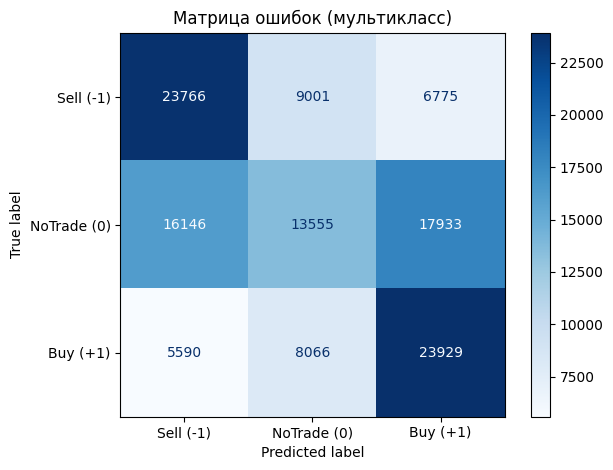

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/class_distribution_mcl.png


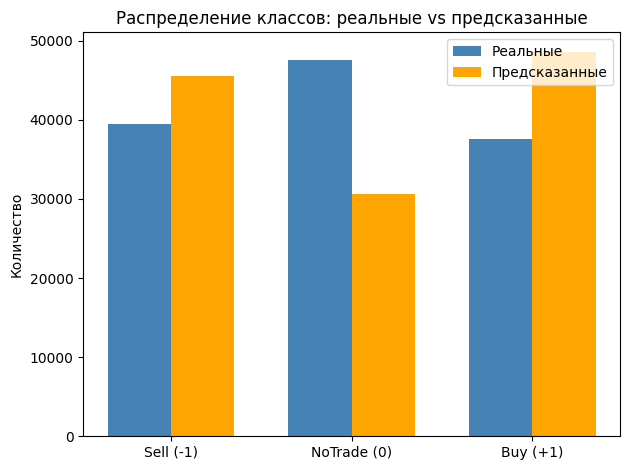

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/softmax_confidence_mcl.png


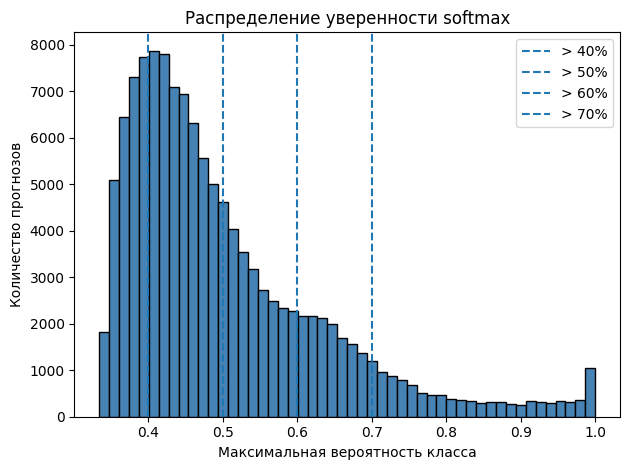

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/loss.png


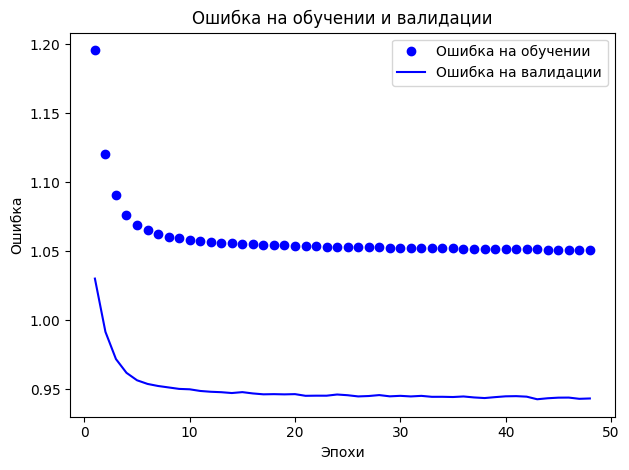

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/accuracy.png


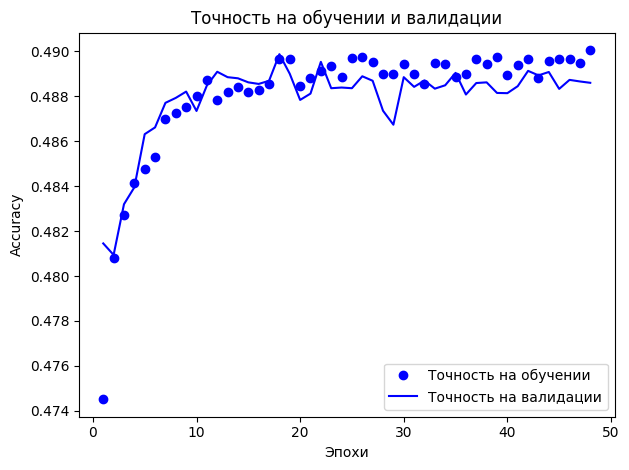

In [1]:
import main

history = main.main()
main.plot_training_history(history)

In [2]:
main.export_model(save_keras=True, save_ONNX=True, model_name="model")

INFO:tensorflow:Assets written to: exports/model_SavedModel/assets


2026-07-11 15:41:37,978 - WARNING - ***IMPORTANT*** Installed protobuf is not cpp accelerated. Conversion will be extremely slow. See https://github.com/onnx/tensorflow-onnx/issues/1557
2026-07-11 15:41:37,980 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-07-11 15:41:38,941 - INFO - Signatures found in model: [serving_default].
2026-07-11 15:41:38,941 - WARNING - '--signature_def' not specified, using first signature: serving_default
2026-07-11 15:41:38,941 - INFO - Output names: ['dense_3']
2026-07-11 15:41:38.947963: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-07-11 15:41:38.948155: I tensorflow/core/grappler/clusters/single_machine.cc:358] Starting new session
2026-07-11 15:41:39.065044: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was

In [3]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("exports/model.onnx")

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

x_sample = main.X_test[:10].astype(np.float32)

keras_pred = main.model.predict(x_sample, verbose=0)
onnx_pred = session.run([output_name], {input_name: x_sample})[0]

print(keras_pred.ravel())
print(onnx_pred.ravel())
print(np.max(np.abs(keras_pred - onnx_pred)))

[0.74233484 0.24913655 0.0085286  0.38580024 0.25451958 0.3596802
 0.6517927  0.29977477 0.04843253 0.0557416  0.29456908 0.6496893
 0.70066744 0.29210705 0.00722551 0.10672419 0.30595514 0.5873206
 0.02397184 0.43993625 0.53609186 0.6184268  0.36996177 0.01161142
 0.00152111 0.28874967 0.70972925 0.69437593 0.30030924 0.00531477]
[0.7423348  0.24913657 0.00852859 0.3858003  0.2545196  0.35968012
 0.65179265 0.2997747  0.04843254 0.05574157 0.29456908 0.6496893
 0.70066744 0.29210705 0.00722551 0.1067242  0.30595514 0.5873206
 0.02397183 0.43993628 0.53609186 0.61842686 0.36996174 0.01161142
 0.00152111 0.28874967 0.7097292  0.6943759  0.30030927 0.00531477]
8.940697e-08


In [4]:
import numpy as np
from config import TASK

# ── Прогнозы на всём тестовом множестве ──────────────────────────────────────
if TASK == "multiclass":
    # Для мультикласса predict возвращает shape (N, 3): [P_sell, P_notrade, P_buy]
    proba        = main.model.predict(main.X_test, verbose=0)   # (N, 3)
    class_pred   = np.argmax(proba, axis=1)                     # 0/1/2
    pred_signals = class_pred - 1                               # -1/0/+1
    confidence   = proba.max(axis=1)                            # уверенность softmax
    # y_test хранит классы 0/1/2 → переводим в -1/0/+1
    y_signals    = main.y_test - 1

elif TASK == "regression":
    # Для регрессии predict возвращает shape (N, 1)
    pred_signals = main.model.predict(main.X_test, verbose=0).ravel()
    confidence   = np.abs(pred_signals)                         # |значение| как уверенность
    y_signals    = main.y_test

else:
    raise ValueError(f"Анализ не реализован для TASK={TASK!r}")

# ── Статистика по таргетам ────────────────────────────────────────────────────
mask_trade = (y_signals != 0)                                   # только Trade-бары (±1)
print(f"Всего тестовых баров:           {len(y_signals)}")
print(f"  из них Trade  (±1):           {mask_trade.sum()}")
print(f"  из них NoTrade (0):           {(~mask_trade).sum()}")
print()

# ── Win rate по порогу уверенности ───────────────────────────────────────────
# Берём только Trade-бары и только те, где уверенность > порога
p_conf  = confidence[mask_trade]
p_sig   = pred_signals[mask_trade] if TASK == "regression" else (class_pred[mask_trade] - 1)
y_sig   = y_signals[mask_trade]

thresh_label = "уверенность softmax" if TASK == "multiclass" else "|pred|"
print(f"{'Порог (' + thresh_label + ')':>28}  {'Сигналов':>9}  {'% охвата':>9}  {'Win rate':>9}")
print("-" * 60)
for thresh in [0.0, 0.33, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    mask_conf = (p_conf > thresh)
    n = mask_conf.sum()
    if n == 0:
        continue
    wins = ((p_sig[mask_conf] > 0) & (y_sig[mask_conf] > 0)) | \
           ((p_sig[mask_conf] < 0) & (y_sig[mask_conf] < 0))
    wr       = wins.sum() / n * 100
    coverage = n / mask_trade.sum() * 100
    print(f"  {thresh:.2f}  {n:>9}  {coverage:>8.1f}%  {wr:>8.1f}%")


Всего тестовых баров:           124761
  из них Trade  (±1):           77127
  из них NoTrade (0):           47634

 Порог (уверенность softmax)   Сигналов   % охвата   Win rate
------------------------------------------------------------
  0.00      77127     100.0%      61.8%
  0.33      77127     100.0%      61.8%
  0.40      60004      77.8%      70.2%
  0.50      30362      39.4%      89.6%
  0.60      17080      22.1%      98.0%
  0.70       8551      11.1%      99.5%
  0.80       4844       6.3%      99.6%
  0.90       2936       3.8%      99.6%
